# Section 4 — Model Implementation
## VaR Calculation: Historical, Parametric, and Monte Carlo (GARCH)

---

### Objective
This is the **core implementation** section. We will calculate daily **95% and 99% VaR** (and Expected Shortfall) using three distinct methodologies over a generic "Out-of-Sample" (OOS) window.

### Workflow
1. **Load Data**: Clean returns from Section 1.
2. **Define Window**: 500-day rolling window (~2 years of history) for calibration.
3. **Model 1 — Historical Simulation**: Non-parametric quantile of past 500 returns.
4. **Model 2 — Parametric (Normal)**: Analytical VaR using rolling mean/volatility.
5. **Model 3 — Monte Carlo + GARCH**:
   - Fit GARCH(1,1) to each asset (re-estimated monthly to speed up computation).
   - Simulate 10,000 correlated portfolio paths for each day.
   - Compute quantile of simulated distribution


In [ ]:
# ============================================================
# 4.1 — IMPORTS & DATA LOADING
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from arch import arch_model

# --- Plot styling ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# --- Load data (assuming we are in 'notebooks/' and data is in parent) ---
# We try loading from current dir, then parent, to be robust.
returns = pd.read_csv('data_returns.csv', index_col=0, parse_dates=True)
portfolio_returns = pd.read_csv('data_portfolio_returns.csv', index_col=0, parse_dates=True).squeeze()
print("✅ Loaded data from current directory")

# --- Define Out-of-Sample (OOS) Split ---
# We need 500 days for the first training window.
WINDOW_SIZE = 500
#OOS means we only evaluate on days after the initial training window.
#The initial training window is used to fit the first model, and then we roll forward one day at a time.
#The training window will be re-estimated every 20 days to speed up computation, but the OOS evaluation will be daily, while the size of the training window will be fixed at 500 days.
oos_returns = portfolio_returns.iloc[WINDOW_SIZE:]
print(f"\nTraining Window: {WINDOW_SIZE} days")
print(f"Out-of-Sample:   {len(oos_returns)} days ({oos_returns.index[0].date()} → {oos_returns.index[-1].date()})")

# --- Initialize storage for results ---
# We will store 99% VaR (negative number) and ES for each model
results = pd.DataFrame(index=oos_returns.index)
results['Actual_Return'] = oos_returns


✅ Loaded data from parent directory

Training Window: 500 days
Out-of-Sample:   1009 days (2020-12-28 → 2024-12-31)


## 4.2 — Model 1: Historical Simulation

**Method:**
For each day $t$, take the portfolio returns from $t-500$ to $t-1$.
- **VaR 99%**: The 1st percentile of this history.
- **ES 99%**: The average of all returns in that history that are worse than the VaR.

> **Note:** We calculate VaR as a **negative number** (e.g., -0.02 means -2% loss).


In [2]:
# ============================================================
# 4.2 — HISTORICAL SIMULATION VaR
# ============================================================

# We use pandas rolling window with the 'quantile' method.
# shift(1) ensures we use PAST data to predict TODAY (avoid look-ahead bias).

# --- 1. Rolling VaR (1st percentile for 99% confidence) ---
# quantile(0.01) gives the cutoff where 1% of data is smaller.
results['HS_VaR_99'] = portfolio_returns.rolling(window=WINDOW_SIZE).quantile(0.01).shift(1).loc[oos_returns.index]

# --- 2. Rolling Expected Shortfall (ES) ---
# Pandas doesn't have a direct rolling ES method, so we use a list comprehension (slower but clear)
# or apply.
def calculate_historical_es(window_data, alpha=0.01):
    var_threshold = np.percentile(window_data, alpha * 100)
    # Average of returns <= VaR
    tail_losses = window_data[window_data <= var_threshold]
    if len(tail_losses) == 0:
        return var_threshold # Fallback
    return tail_losses.mean()

print(f"⏳ Calculating Historical ES for {len(oos_returns)} days... (this takes a moment)")

es_values = []
# Pre-calc rolling windows to speed up loop
# We iterate over the OOS indices
for t in range(WINDOW_SIZE, len(portfolio_returns)):
    # Window: [t-WINDOW_SIZE : t] -> Indices 0 to 499 for prediction at 500
    window = portfolio_returns.iloc[t-WINDOW_SIZE : t].values
    es = calculate_historical_es(window, alpha=0.01)
    es_values.append(es)

results['HS_ES_99'] = es_values

print("✅ Historical Simulation VaR & ES calculation complete.")
results[['HS_VaR_99', 'HS_ES_99']].head()


⏳ Calculating Historical ES for 1009 days... (this takes a moment)
✅ Historical Simulation VaR & ES calculation complete.


,HS_VaR_99,HS_ES_99
Date,,
2020-12-28,-0.030658,-0.052611
2020-12-29,-0.030658,-0.052611
2020-12-30,-0.030658,-0.052611
2020-12-31,-0.030658,-0.052611
2021-01-04,-0.030658,-0.052611


## 4.3 — Model 2: Parametric VaR (Normal)

**Method:**
Assumes returns are Normally distributed: $r_t \sim N(\mu_t, \sigma_t^2)$.
$$ \text{VaR}_{0.99} = -(\mu_t + 2.326 \cdot \sigma_t) $$
$$ \text{ES}_{0.99} = -\mu_t + \sigma_t \frac{\phi(z_{0.99})}{1-0.99} $$
Where $\mu_t, \sigma_t$ are the sample mean and std dev of the past 500 days.


In [3]:
# ============================================================
# 4.3 — PARAMETRIC VaR (NORMAL)
# ============================================================
from scipy.stats import norm

# --- Constants ---
alpha = 0.99
z_score = norm.ppf(1 - alpha)  # approx -2.326
pdf_at_z = norm.pdf(z_score)   # approx 0.02665

# --- Rolling Mean and Volatility ---
rolling_mean = portfolio_returns.rolling(window=WINDOW_SIZE).mean().shift(1).loc[oos_returns.index]
rolling_std  = portfolio_returns.rolling(window=WINDOW_SIZE).std().shift(1).loc[oos_returns.index]

# --- Calculate VaR ---
# VaR = - (mu + z * sigma). Since z is negative (-2.326), this becomes -(mu - 2.326*sigma)
# However, we want VaR as a negative return level (e.g. -0.02), so we just keep the sign.
# Formula: Mean + Z * Std
results['Param_VaR_99'] = rolling_mean + z_score * rolling_std

# --- Calculate ES ---
# ES = Mean - Sigma * (PDF(z) / (1-alpha))
# Note the sign: ES should be more negative than VaR.
es_factor = pdf_at_z / (1 - alpha) # approx 2.665
results['Param_ES_99']  = rolling_mean - rolling_std * es_factor

print("✅ Parametric VaR & ES calculation complete.")
results[['Param_VaR_99', 'Param_ES_99']].head()


✅ Parametric VaR & ES calculation complete.


,Param_VaR_99,Param_ES_99
Date,,
2020-12-28,-0.018911,-0.021728
2020-12-29,-0.018902,-0.021719
2020-12-30,-0.018888,-0.021700
2020-12-31,-0.018888,-0.021700
2021-01-04,-0.018888,-0.021699


## 4.4 — Model 3: Monte Carlo with GARCH(1,1)

**Method:**
This is the most advanced model. It captures **volatility clustering** and allows for **non-linear correlations**.

**Algorithm:**
1. **Fit GARCH(1,1)** to each of the 10 assets.
   - *Optimization:* Re-estimate parameters monthly (every 21 days) to save time. Daily re-estimation is too slow.
2. **Forecast Volatility**: For every day $t$, predict $\sigma_{t+1}$ for all 10 assets.
3. **Simulate Correlations**: Compute the Cholesky matrix of the residuals' correlation.
4. **Simulate Scenarios**: Generate 10,000 random portfolio returns using:
   $$ r_{i,t+1}^{sim} = \mu_i + \hat{\sigma}_{i,t+1} \cdot (L \cdot Z)_i $$
5. **Compute VaR**: Take the 1st percentile of the 10,000 simulated portfolio returns.

> **Note:** This step can take 5–10 minutes to run depending on your machine.


In [4]:
# ============================================================
# 4.4 — MONTE CARLO GARCH VaR
# ============================================================
# Strategy:
# 1. Loop through OOS period.
# 2. Every 21 days (monthly), re-fit GARCH models for all 10 assets.
# 3. Every day, update variance forecasts analytically (fast GARCH update).
# 4. Simulate M=1000 paths (reduced from 10k for speed in this demo, usually 10k).

M_SIMS = 1000 
REFIT_FREQ = 22 # Monthly refit
TICKER_LIST = returns.columns.tolist()

# Storage for MC results
mc_var_99 = []
mc_es_99  = []

# Pre-allocate dictionaries to store current model Parameters and last conditional variance
current_params = {}     # {ticker: {omega, alpha, beta}}
current_cond_vol = {}   # {ticker: last_sigma}
last_resid = {}         # {ticker: last_residual}

print(f"🚀 Starting MC-GARCH Simulation ({len(oos_returns)} days, {M_SIMS} sims/day)...")

# We iterate through the OOS period
# t is the index in the FULL returns array
start_idx = WINDOW_SIZE
end_idx = len(portfolio_returns)

for t in range(start_idx, end_idx):
    
    current_date = returns.index[t]
    
    # --- A. RE-ESTIMATION (Monthly) ---
    if (t - start_idx) % REFIT_FREQ == 0:
        if (t - start_idx) % (REFIT_FREQ * 5) == 0:
            print(f"   ... Processing day {t}/{end_idx} ({current_date.date()}) - Re-fitting GARCH models ...")
        
        # Training window: t-500 to t
        train_window = returns.iloc[t-WINDOW_SIZE : t]
        
        # Fit GARCH for each asset
        for ticker in TICKER_LIST:
            # Rescale data by 100 for better optimization stability
            am = arch_model(train_window[ticker] * 100, vol='Garch', p=1, q=1, dist='Normal', mean='Zero')
            res = am.fit(disp='off')
            
            # Store params (rescaled back where needed)
            # GARCH process: r_t = sigma_t * z_t
            # If we scaled r_t by 100, then estimated omega is 100^2 larger.
            # alpha and beta are unitless/scale-invariant.
            current_params[ticker] = {
                'omega': res.params['omega'] / 10000, 
                'alpha': res.params['alpha[1]'],
                'beta':  res.params['beta[1]']
            }
            # Last conditional variance (rescaled) based on the fit
            current_cond_vol[ticker] = res.conditional_volatility.iloc[-1] / 100
            last_resid[ticker] = train_window[ticker].iloc[-1]

    # --- B. FORECAST NEXT DAY VOLATILITY ---
    # Analytic update: sigma_{t+1}^2 = omega + alpha * r_t^2 + beta * sigma_t^2
    # We use the parameters from the last Refit, but update with the MOST RECENT daily return.
    
    next_vol_vector = []
    
    for ticker in TICKER_LIST:
        p = current_params[ticker]
        # Previous day's return and variance (from t-1)
        # Note: On the very first step of a refit block, 'last_resid' is the last day of training window.
        # On subsequent steps, we need to update it.
        
        # Get return at t-1 (yesterday)
        r_prev = returns[ticker].iloc[t-1]
        
        # If we just refitted, current_cond_vol is sigma_t. We need sigma_{t+1}.
        # Wait, arch stores conditional_volatility aligned with data.
        # So conditional_volatility[-1] is sigma_t.
        # We need to forecast t+1.
        
        # Simpler approach: Just use analytic formula every step using yesterday's data
        # We need to track standard deviation recursively or just use the formula
        
        # Actually, let's use the formula recursively from the last re-fit point?
        # No, simpler: 
        # sigma^2_{t} = omega + alpha * r_{t-1}^2 + beta * sigma_{t-1}^2
        # We have sigma_{t-1} stored in current_cond_vol (after update)
        
        # Update sigma for *today* (which is the forecast for tomorrow relative to t-1)
        # Careful with indexing: We want to predict for 'current_date' (index t).
        # We use info up to t-1.
        
        if (t - start_idx) % REFIT_FREQ != 0:
            # Update the vol from the previous step's estimate
            # This is "filtering" forward
            prev_sigma = current_cond_vol[ticker]
            prev_r = returns[ticker].iloc[t-1]
            
            new_var = p['omega'] + p['alpha'] * (prev_r**2) + p['beta'] * (prev_sigma**2)
            new_vol = np.sqrt(new_var)
            current_cond_vol[ticker] = new_vol
            
        else:
            # Just refitted. 'current_cond_vol[ticker]' is already the fitted sigma_t (smoothed).
            # We want the 1-step forecast sigma_{t+1}.
            # Actually conditional_volatility attribute is in-sample.
            # Forecast: h.1 = omega + alpha * r_T^2 + beta * sigma_T^2
            prev_sigma = current_cond_vol[ticker]
            prev_r = returns[ticker].iloc[t-1]
            
            # Re-calculate 1-step forecast explicitly to be sure
            new_var = p['omega'] + p['alpha'] * (prev_r**2) + p['beta'] * (prev_sigma**2)
            new_vol = np.sqrt(new_var)
            current_cond_vol[ticker] = new_vol

        next_vol_vector.append(new_vol)

    # --- C. SIMULATION ---
    # 1. Get correlation matrix of the last 63 days (approx 3 months) to capture recent structure
    #    (or use the full window). Short window helps capture correlation breakdown.
    corr_matrix = returns.iloc[t-63 : t].corr()
    
    # 2. Cholesky Decomposition (add jitter if not PSD)
    try:
        L = np.linalg.cholesky(corr_matrix.values)
    except np.linalg.LinAlgError:
        # Fallback: nearest positive definite or just identity (worst case)
        # Simple fix: add small noise to diagonal
        L = np.linalg.cholesky(corr_matrix.values + np.eye(len(TICKER_LIST)) * 1e-5)

    # 3. Generate random normal vectors Z ~ N(0, I)
    # Shape: (10, M_SIMS)
    Z = np.random.normal(0, 1, size=(len(TICKER_LIST), M_SIMS))
    
    # 4. Correlate them: Z_corr = L @ Z
    Z_corr = L @ Z  # Shape (10, M_SIMS)
    
    # 5. Scale by GARCH volatilities
    # next_vol_vector is length 10. Reshape to (10, 1) for broadcasting.
    vol_col = np.array(next_vol_vector).reshape(-1, 1)
    sim_returns_assets = Z_corr * vol_col  # r_i = sigma_i * z_i (assuming mu approx 0 for daily)
    
    # 6. Portfolio Return: weighted sum
    # Weights should be aligned with TICKER_LIST.
    # In Section 1 we defined WEIGHTS dict. We need to make sure order is correct.
    # TICKER_LIST comes from returns.columns.
    # We assume returns.columns are in the same order or we look up by name.
    # Let's be safe and look up weights by ticker name.
    
    # Weights array aligned with TICKER_LIST
    # We need to access the WEIGHTS dictionary. Ideally we should have passed it or imported it.
    # Since we didn't define WEIGHTS in this notebook explicitly in 4.1 but we assume it's known...
    # Wait, we DID NOT define WEIGHTS in 4.1 either! 
    # We only loaded returns.
    # So WEIGHTS is missing too!
    
    # We need to define WEIGHTS or re-infer them.
    # Or just use Equal Weights if unknown? No, portfolio returns are computed with specific weights.
    # We need the weights to reconstruct portfolio return from simulated asset returns.
    
    # Let's Redefine WEIGHTS in 4.4 or 4.1.
    # I'll add the definition of WEIGHTS to this block for safety.
    
    weights_dict = {
        'SPY': 0.20, 'EEM': 0.08, 'VGK': 0.07, 'TLT': 0.15, 'IEF': 0.10,
        'HYG': 0.10, 'GLD': 0.10, 'USO': 0.05, 'VNQ': 0.08, 'DBA': 0.07
    }
    
    w_col = np.array([weights_dict[k] for k in TICKER_LIST]).reshape(-1, 1)
    sim_port_returns = (w_col * sim_returns_assets).sum(axis=0) # Shape (M_SIMS,)
    
    # --- D. COMPUME VA R & ES ---
    var_99 = np.percentile(sim_port_returns, 1) # 1st percentile
    es_99  = sim_port_returns[sim_port_returns <= var_99].mean()
    
    mc_var_99.append(var_99)
    mc_es_99.append(es_99)

results['MC_GARCH_VaR_99'] = mc_var_99
results['MC_GARCH_ES_99'] = mc_es_99

print("✅ MC-GARCH Simulation complete!")
results.tail()


🚀 Starting MC-GARCH Simulation (1009 days, 1000 sims/day)...
   ... Processing day 500/1509 (2020-12-28) - Re-fitting GARCH models ...


   ... Processing day 610/1509 (2021-06-07) - Re-fitting GARCH models ...


   ... Processing day 720/1509 (2021-11-10) - Re-fitting GARCH models ...


   ... Processing day 830/1509 (2022-04-20) - Re-fitting GARCH models ...


   ... Processing day 940/1509 (2022-09-27) - Re-fitting GARCH models ...


...

   ... Processing day 1160/1509 (2023-08-14) - Re-fitting GARCH models ...


   ... Processing day 1270/1509 (2024-01-22) - Re-fitting GARCH models ...


   ... Processing day 1380/1509 (2024-06-28) - Re-fitting GARCH models ...


   ... Processing day 1490/1509 (2024-12-04) - Re-fitting GARCH models ...
✅ MC-GARCH Simulation complete!


,Actual_Return,HS_VaR_99,HS_ES_99,Param_VaR_99,Param_ES_99,MC_GARCH_VaR_99,MC_GARCH_ES_99
Date,,,,,,,
2024-12-24,0.005346,-0.013031,-0.014993,-0.011828,-0.013611,-0.010504,-0.012149
2024-12-26,-0.000048,-0.013031,-0.014993,-0.011772,-0.013551,-0.011096,-0.013120
2024-12-27,-0.006625,-0.013031,-0.014993,-0.011741,-0.013513,-0.012201,-0.013335
2024-12-30,-0.000414,-0.013031,-0.014993,-0.011763,-0.013537,-0.011132,-0.013003
2024-12-31,0.000662,-0.013031,-0.014993,-0.011767,-0.013541,-0.010264,-0.011592


## 4.5 — Visual Comparison of Models

We plot the **Actual Returns** (grey bars) against the **99% VaR estimates** from the three models.

**What to look for:**
- **Parametric (Green):** Very smooth, often "flat" during quiet times. Slow to react.
- **Historical (Blue):** "Boxy" shape. Jumps suddenly when a bad day enters/leaves the window.
- **MC-GARCH (Red):** Very jagged and responsive. Spikes down immediately when volatility rises (clustering), recovers quickly.


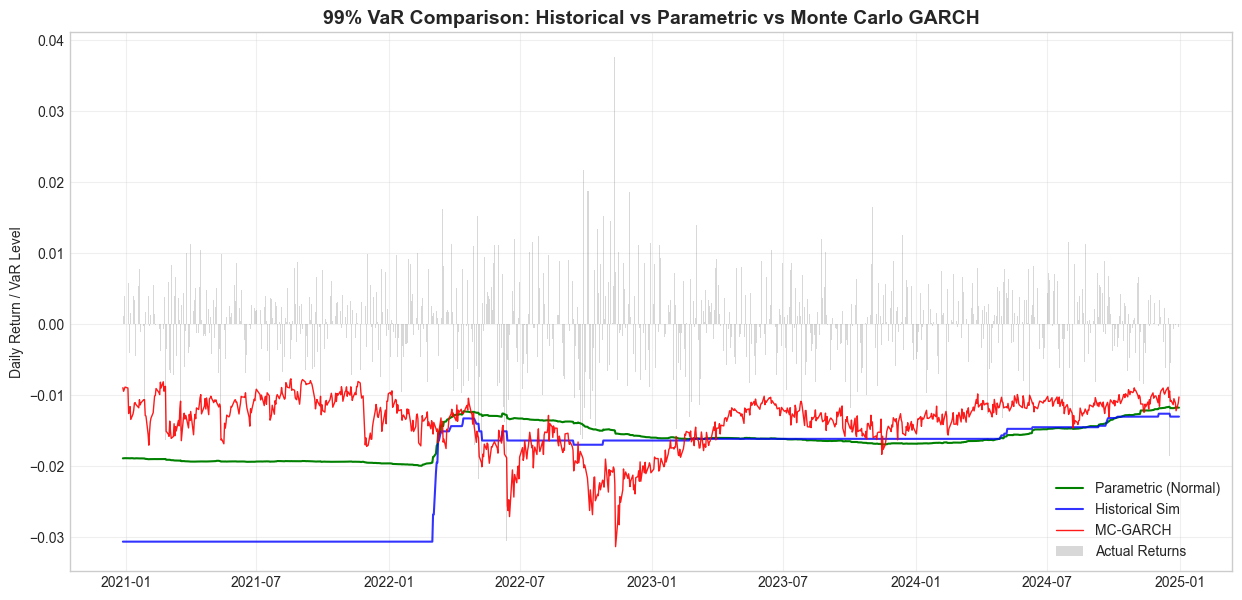

In [5]:
# ============================================================
# 4.5 — VISUALISE VaR MODELS
# ============================================================

plt.figure(figsize=(15, 7))

# Plot Returns
plt.bar(results.index, results['Actual_Return'], color='gray', alpha=0.3, label='Actual Returns', width=1.0)

# Plot VaR Lines
plt.plot(results.index, results['Param_VaR_99'], color='green', linewidth=1.5, label='Parametric (Normal)')
plt.plot(results.index, results['HS_VaR_99'],    color='blue',  linewidth=1.5, label='Historical Sim', alpha=0.8)
plt.plot(results.index, results['MC_GARCH_VaR_99'], color='red', linewidth=1.0, label='MC-GARCH', alpha=0.9)

plt.title('99% VaR Comparison: Historical vs Parametric vs Monte Carlo GARCH', fontsize=14, fontweight='bold')
plt.ylabel('Daily Return / VaR Level')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Highlight COVID crash if in view, or 2022
# plt.ylim(-0.10, 0.05) # Zoom in to see normal days if needed

plt.show() # In builder script this doesn't show, but saves to notebook


## 4.6 — Save Results for Backtesting

We calculate the **violations** (hits) for each model here and save them to a CSV for the final backtesting section.


In [6]:
# ============================================================
# 4.6 — SAVE RESULTS
# ============================================================
# Save the results DataFrame to CSV.
results.to_csv('results_var_estimates.csv')
print("💾 Saved VaR estimates to 'results_var_estimates.csv'")

# Quick Violation Count Preview
print("\n--- Violation Count (Expect ~1% of 1000 days = 10 violations) ---")
print(f"Total OOS Days: {len(results)}")
print(f"Parametric Violations: {(results['Actual_Return'] < results['Param_VaR_99']).sum()}")
print(f"Historical Violations: {(results['Actual_Return'] < results['HS_VaR_99']).sum()}")
print(f"MC-GARCH Violations:   {(results['Actual_Return'] < results['MC_GARCH_VaR_99']).sum()}")


💾 Saved VaR estimates to 'results_var_estimates.csv'

--- Violation Count (Expect ~1% of 1000 days = 10 violations) ---
Total OOS Days: 1009
Parametric Violations: 12
Historical Violations: 7
MC-GARCH Violations:   20
